# Security filters · 1. Presentation curve

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ula-uab/lscm-decision-making/blob/main/cases/security_filters/notebooks/01_presentation_curve.ipynb)

How many passengers arrive at the airport security filters in each 5-minute slot of a day? This notebook builds that curve, the **presentation curve**, from the flight schedule of the day and the way passengers arrive before their flight.

| Notebook | Question |
|---|---|
| 1. Presentation curve | How is the curve built from the flight schedule? |
| 2. Demand scenarios | What could the demand at the filters be, under different assumptions? |
| 3. Lane policies | How many lanes should be open in each period of the day? |
| 4. After the day | How good were the scenarios and the policies, against what really happened? |

In [1]:
# In Google Colab, install the package from GitHub (it takes a few seconds).
# On your own computer, install the repository environment instead (see README).
import sys
if "google.colab" in sys.modules:
    %pip install -q "git+https://github.com/ula-uab/lscm-decision-making#subdirectory=cases/security_filters"

In [2]:
import security_filters as sf
from security_filters.plots import plot_curves, plot_profiles

## 1. The flight schedule

Each row is a departing flight: date, flight number, departure time, destination, number of seats and airline (the first three letters of the flight number). The schedule covers several weeks of July 2008.

In [3]:
schedule = sf.read_schedule()
schedule.head()

,date,flight,departure,destination,seats,departure_minute,airline
0,2008-07-18,AEA6012,06:00,MAD,186,360,AEA
1,2008-07-19,FUA1449,05:10,GLA,150,310,FUA
2,2008-07-16,FUA8431,06:55,KTW,168,415,FUA
3,2008-07-18,MYW500P,18:20,VCE,170,1100,MYW
4,2008-07-16,FUA7821,06:25,CGN,149,385,FUA


In [4]:
sf.days(schedule)

date
2008-07-16    316
2008-07-17    297
2008-07-18    353
2008-07-19    430
2008-07-20    421
2008-07-21    291
2008-07-22    337
2008-07-23    313
2008-07-24    302
2008-07-25    353
2008-07-26    441
2008-07-27    429
2008-07-28    302
2008-07-29    346
2008-07-30    331
2008-07-31    308
2008-08-01     24
2008-08-02      1
2008-08-03      1
2008-08-04      1
Name: flights, dtype: int64

Choose a day. Its flights are the input of the curve.

In [5]:
day = "2008-07-19"
flights = sf.flights_of_day(schedule, day)
print(f"{len(flights)} flights, {flights['seats'].sum()} seats")
flights.head()

430 flights, 75977 seats


,date,flight,departure,destination,seats,departure_minute,airline
0,2008-07-19,TOM3472,00:15,LGW,189,15,TOM
1,2008-07-19,TCX145L,01:20,BHX,235,80,TCX
2,2008-07-19,BMA7254,01:50,MAN,156,110,BMA
3,2008-07-19,JKK4369,03:15,ETZ,167,195,JKK
4,2008-07-19,BAW2703,03:40,LGW,110,220,BAW


## 2. How passengers arrive: arrival profiles

A profile gives the fraction of the passengers of a flight that arrive at the filters in each 5-minute interval before departure. Interval 1 is the 5 minutes just before departure. These are the five profiles of the original Excel workbook; notebook 2 introduces profiles defined by type of flight.

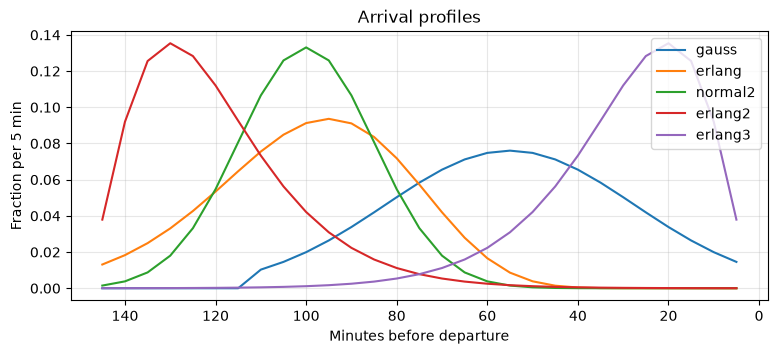

In [6]:
profiles = sf.read_profiles()
plot_profiles(profiles);

## 3. The presentation curve

Each flight spreads its passengers over the slots before its departure following the profile. Adding all flights gives the curve. Early flights of the next day are included too, because some of their passengers arrive before midnight.

Passengers arriving on 2008-07-19: 77266
Busiest slot: 08:25 with 468 passengers


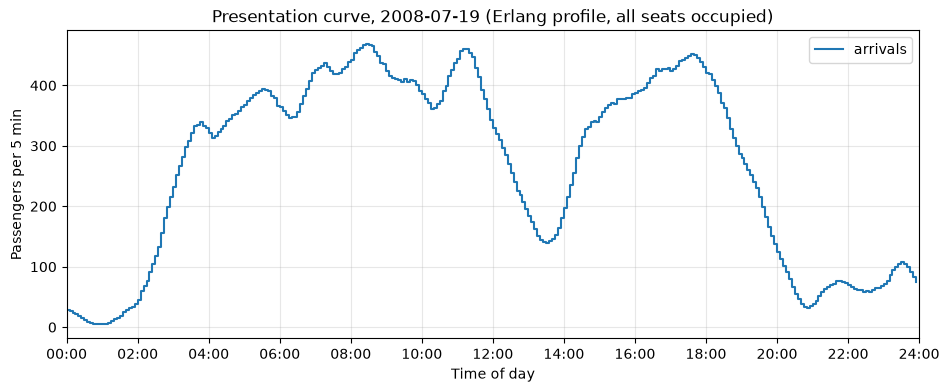

In [7]:
flights_curve = sf.flights_for_curve(schedule, day)
curve = sf.presentation_curve(flights_curve, profiles, profile="erlang", load_factor=1.0)
print(f"Passengers arriving on {day}: {curve.sum():.0f}")
print(f"Busiest slot: {curve.idxmax()} with {curve.max():.0f} passengers")
plot_curves(curve, title=f"Presentation curve, {day} (Erlang profile, all seats occupied)");

In [8]:
sf.hourly(curve).round(0).to_frame("passengers per hour").T

hour,00:00,01:00,02:00,03:00,04:00,05:00,06:00,07:00,08:00,09:00,...,14:00,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00
passengers per hour,175.0,231.0,1445.0,3628.0,4047.0,4585.0,4444.0,5134.0,5459.0,4898.0,...,3476.0,4448.0,4932.0,5279.0,4340.0,2582.0,819.0,765.0,758.0,1092.0


## 4. Comparison with the original Excel macro

The original case computed this curve with an Excel macro. `legacy_presentation_curve` reproduces it exactly, errors included (the tests check it against the workbook). The macro ignored the last interval of the profile, rounded passengers flight by flight and lost the remainder, skipped flights leaving before 00:40 and did not count passengers of the next day's early flights.

Excel macro: 74631 passengers
Corrected:   77266 passengers


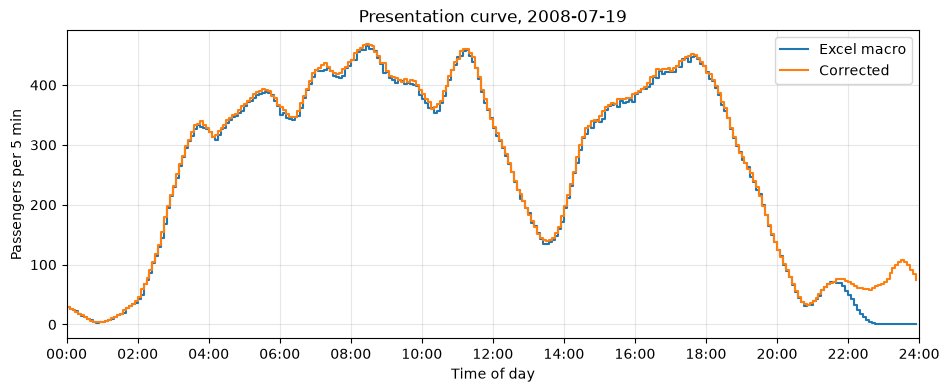

In [9]:
from security_filters.legacy import legacy_presentation_curve

legacy = legacy_presentation_curve(flights, profiles, profile="erlang")
print(f"Excel macro: {legacy.sum():.0f} passengers")
print(f"Corrected:   {curve.sum():.0f} passengers")
plot_curves({"Excel macro": legacy, "Corrected": curve}, title=f"Presentation curve, {day}");

## 5. Try it yourself

- Change `day` and compare a weekday with a Saturday.
- Change `profile` to `"gauss"` or `"normal2"`: how does the peak move?
- Use `load_factor=0.8`: what if only 80 % of the seats are occupied?